### Exploratory Data Analysis (EDA)

This notebook serves to conduct exploratory data analysis on the dataset.

### 1. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import warnings
import re
import re
import html
from bs4 import BeautifulSoup


warnings.filterwarnings('ignore')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\Iris\anaconda3\Lib\site-packages

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



### 2. Loading Dataset

In [2]:
data_path = Path('data/raw/fake_job_postings.csv')
df_source = pd.read_csv(data_path)
df = df_source.copy(deep=True)

print(df.shape)
print(df.info())
print(df.describe())
print(df.columns.tolist())


(17880, 18)
<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             

>The dataset has `17,880 rows` and `18 columns`.
>
>The columns are `job_id`, `title`, `location`, `department`, `salary_range`, `company_profile`, `description`, `requirements`, `benefits`, `telecommuting`, `has_company_logo`, `has_questions`, `employment_type`, `required_experience`, `required_education`, `industry`, `function`, `fraudulent`.
>
>There are `5 numerical int64 columns` (job_id, telecommuting, has_company_logo, has_questions, fraudulent), while the rest are text str columns.

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### 3. Data Cleaning

This section serves to clean the dataset by handling inconsistencies in strings, null or empty values, etc.


In [4]:
df.isnull().sum().sort_values(ascending=False)


salary_range           15012
department             11547
required_education      8105
benefits                7212
required_experience     7050
function                6455
industry                4903
employment_type         3471
company_profile         3308
requirements            2696
location                 346
description                1
title                      0
job_id                     0
telecommuting              0
has_questions              0
has_company_logo           0
fraudulent                 0
dtype: int64

In [5]:
df.isnull().mean() * 100

job_id                  0.000000
title                   0.000000
location                1.935123
department             64.580537
salary_range           83.959732
company_profile        18.501119
description             0.005593
requirements           15.078300
benefits               40.335570
telecommuting           0.000000
has_company_logo        0.000000
has_questions           0.000000
employment_type        19.412752
required_experience    39.429530
required_education     45.329978
industry               27.421700
function               36.101790
fraudulent              0.000000
dtype: float64

Given that salary range has 84.0% missing values and department has 64.5% missing values, can consider dropping these features since they are too sparse to extract meaning. We will transform `salary_range` to `salary_provided boolean column` instead.

In [6]:
placeholders = ['n/a', 'na', 'none', 'null', '-', '?', 'not specified', 'unknown', 'other']
for col in df.select_dtypes(include='object').columns:
    mask = df[col].str.strip().str.lower().isin(placeholders)
    count = mask.sum()
    if count > 0:
        print(f"column name({col}): {count} placeholder values")
        print(df[col][mask].value_counts())
        print('\n')

column name(department): 2 placeholder values
department
Unknown    1
Other      1
Name: count, dtype: int64


column name(benefits): 1 placeholder values
benefits
na    1
Name: count, dtype: int64


column name(employment_type): 227 placeholder values
employment_type
Other    227
Name: count, dtype: int64


column name(function): 325 placeholder values
function
Other    325
Name: count, dtype: int64




In [7]:
df['benefits'] = df['benefits'].replace('na', np.nan)
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
str_cols =  ['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']
num_cols = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
text_cols = ['company_profile', 'description', 'requirements', 'benefits']
cat_cols = ['location', 'employment_type', 'required_experience', 
            'required_education', 'industry', 'function']
binary_cols = ['telecommuting', 'has_company_logo', 'has_questions']
target = 'fraudulent'
to_drop = ['job_id', 'department', 'salary_range']

df[text_cols] = df[text_cols].fillna('Not Provided')
df[cat_cols] = df[cat_cols].fillna('Not Provided')

df.isnull().sum()

job_id                     0
title                      0
location                   0
department             11553
salary_range           15012
company_profile            0
description                0
requirements               0
benefits                   0
telecommuting              0
has_company_logo           0
has_questions              0
employment_type            0
required_experience        0
required_education         0
industry                   0
function                   0
fraudulent                 0
dtype: int64

We will `drop job_id column` as ids do not have any predictice power over whether selected job is fradulent

In [8]:
df = df.drop(['job_id'], axis=1)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   title                17880 non-null  str  
 1   location             17880 non-null  str  
 2   department           6327 non-null   str  
 3   salary_range         2868 non-null   str  
 4   company_profile      17880 non-null  str  
 5   description          17880 non-null  str  
 6   requirements         17880 non-null  str  
 7   benefits             17880 non-null  str  
 8   telecommuting        17880 non-null  int64
 9   has_company_logo     17880 non-null  int64
 10  has_questions        17880 non-null  int64
 11  employment_type      17880 non-null  str  
 12  required_experience  17880 non-null  str  
 13  required_education   17880 non-null  str  
 14  industry             17880 non-null  str  
 15  function             17880 non-null  str  
 16  fraudulent           17880 non-nu

given that the location column can be split into `country`, `state`, `city`, We will create 3 additional columns country, state and city.

In [9]:
df['location'].head()
df[["country","state","city"]] = df["location"].str.split(",", n=2, expand=True)

#top 5 countries
df["country"].value_counts().head(5)

country
US    10656
GB     2384
GR      940
CA      457
DE      383
Name: count, dtype: int64

we count the number of values with missing states or cities.

In [10]:
df[["state", "city","country"]].isna().sum()
df.loc[df['city'] == '', 'city'] = 'Not Provided'
df.loc[df['state'] == '', 'state'] = 'Not Provided'
df.loc[df['country'] == '', 'country'] = 'Not Provided'
df['city'] = df['city'].fillna('Not Provided')
df['state'] = df['state'].fillna('Not Provided')
df['country'] = df['country'].fillna('Not Provided')

In [11]:
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,country,state,city
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,Not Provided,0,1,0,Other,Internship,Not Provided,Not Provided,Marketing,0,US,NY,New York
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Not Provided,Marketing and Advertising,Customer Service,0,NZ,,Auckland
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,Not Provided,0,1,0,Not Provided,Not Provided,Not Provided,Not Provided,Not Provided,0,US,IA,Wever
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,US,DC,Washington
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,US,FL,Fort Worth


### 4. Univariate Analysis

#### (a) Numerical Column Analysis 

Analyze the distributions and spread of numerical data in the numerical data columns.

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
telecommuting,17880.0,0.042897,0.202631,0.0,0.0,0.0,0.0,1.0
has_company_logo,17880.0,0.795302,0.403492,0.0,1.0,1.0,1.0,1.0
has_questions,17880.0,0.491723,0.499945,0.0,0.0,0.0,1.0,1.0
fraudulent,17880.0,0.048434,0.214688,0.0,0.0,0.0,0.0,1.0


>Only `telecommuting` , `has_company_logo`, `has_questions` and `fradulent `columns are numeric and since we have dropped the job_id column, these four are the only columns we can do statistical description of its data spread.

##### Telecommunting


Telecommuting distribution:
telecommuting
0    95.710291
1     4.289709
Name: proportion, dtype: float64


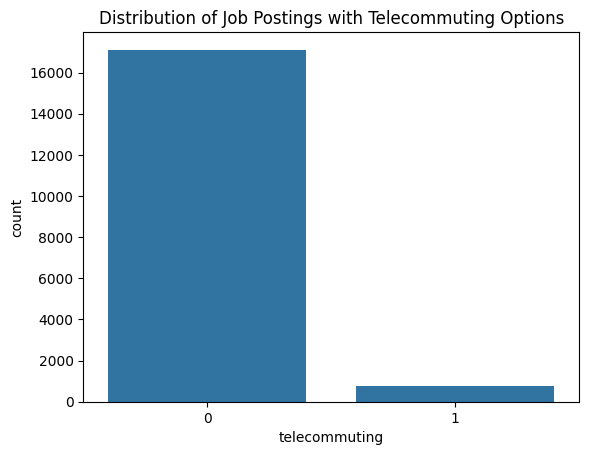

In [13]:
print("\nTelecommuting distribution:")
print(df['telecommuting'].value_counts(normalize=True) * 100)

sns.countplot(x=df['telecommuting'])
plt.title('Distribution of Job Postings with Telecommuting Options')
plt.show()

>we can see that most jobs `do not involve telecommunting`

##### Company Logo


Has Company Logo distribution:
has_company_logo
1    79.530201
0    20.469799
Name: proportion, dtype: float64


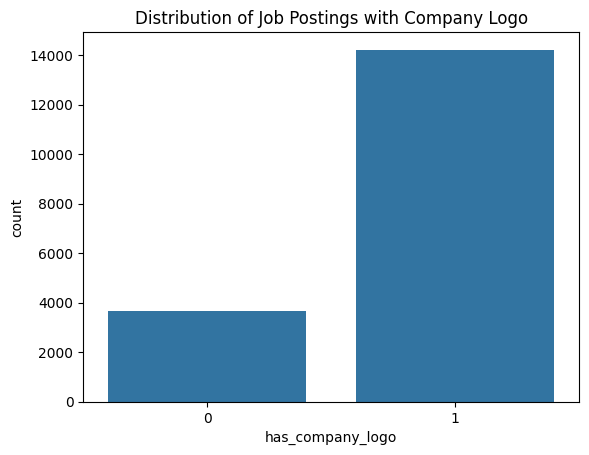

In [14]:
print("\nHas Company Logo distribution:")
print(df['has_company_logo'].value_counts(normalize=True) * 100)

sns.countplot(x=df['has_company_logo'])
plt.title('Distribution of Job Postings with Company Logo')
plt.show()

> Majority of job posting `do have a company logo`

##### Telecommunting


Has Questions distribution:
has_questions
0    50.82774
1    49.17226
Name: proportion, dtype: float64


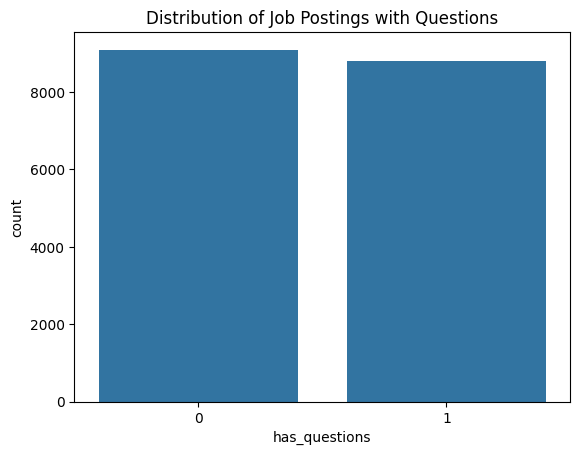

In [15]:
print("\nHas Questions distribution:")
print(df['has_questions'].value_counts(normalize=True) * 100)

sns.countplot(x=df['has_questions'])
plt.title('Distribution of Job Postings with Questions')
plt.show()

>`Roughly even split` in whether screening questions are present in the job posting.


Fraudulent distribution:
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


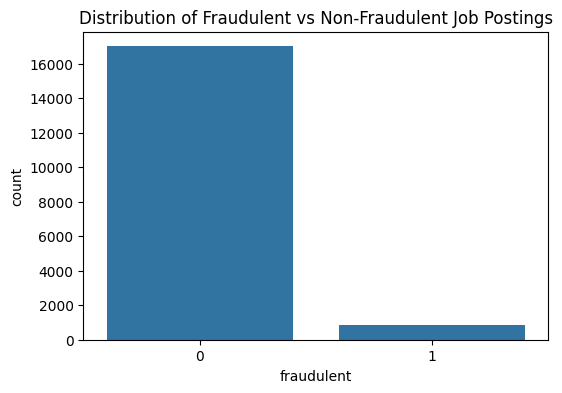

In [16]:
print("\nFraudulent distribution:")
print(df['fraudulent'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent',data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Job Postings')
plt.show()

>majority of all jobs are not fradulent

#### (b) Categorical Column Analysis

Analyze how different categories in each column lead to proportions of job postings to be fradulent or not.

Serves to capture relationships on where certain types of categories have a larger percentage of fraduluent job postings.

In [17]:
print(f"Number of employment types: {df['employment_type'].value_counts().size}")

Number of employment types: 6


##### Employment Type

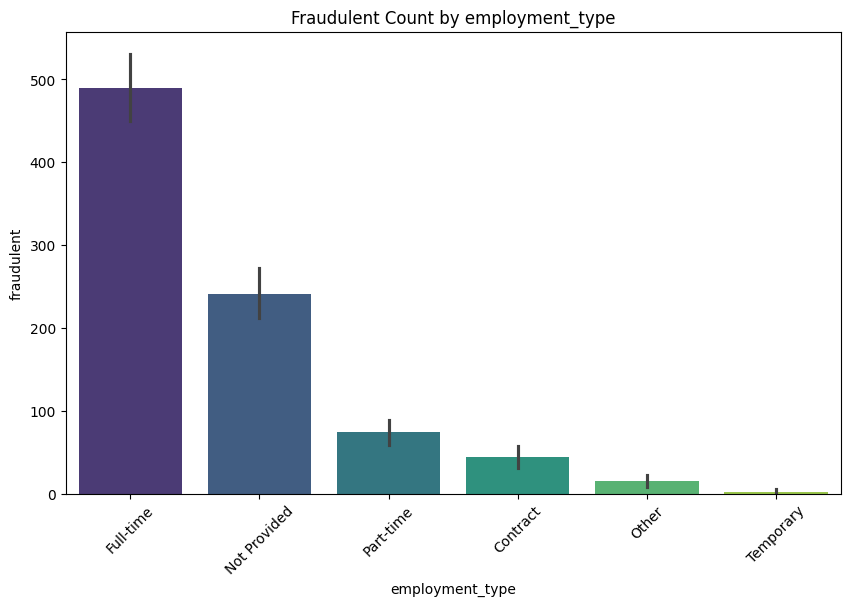

In [18]:
plt.figure(figsize=(10,6))
order = df.groupby('employment_type')['fraudulent'].sum().sort_values(ascending=False).index
sns.barplot(x='employment_type', y='fraudulent', data=df, palette='viridis', estimator=sum, order=order)
plt.title(f'Fraudulent Count by employment_type')
plt.xticks(rotation=45)
plt.show()

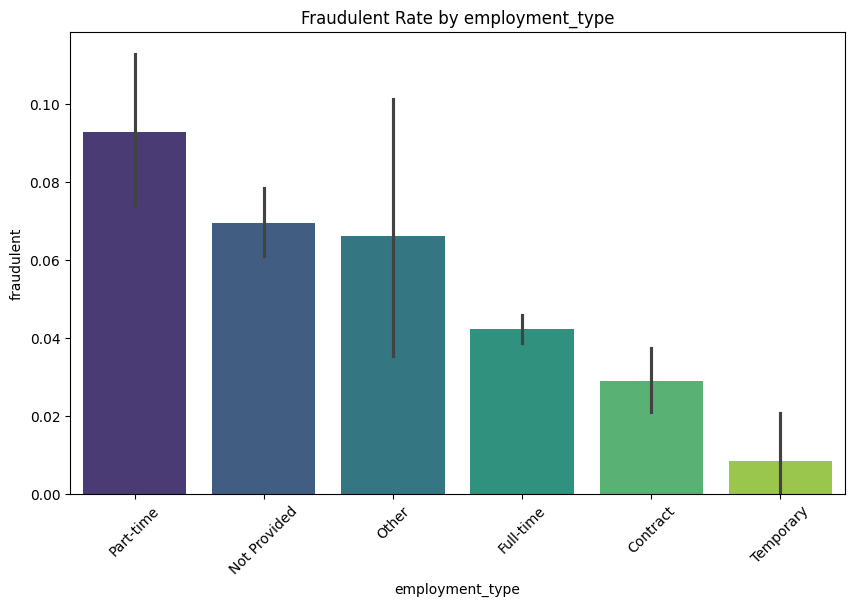

In [19]:
plt.figure(figsize=(10,6))
order = df.groupby('employment_type')['fraudulent'].mean().sort_values(ascending=False).index
sns.barplot(x='employment_type', y='fraudulent', data=df, palette='viridis', order=order)
plt.title(f'Fraudulent Rate by employment_type')
plt.xticks(rotation=45)
plt.show()

>Majority of fraudulent job postings are for `full time positions`.
>
>However, we see that part-time job postings have the `greatest proportion of fraudulent job postings`.

##### Required Experience

In [20]:
print(f"Number of required experience levels: {df['required_experience'].value_counts().size}")

Number of required experience levels: 8


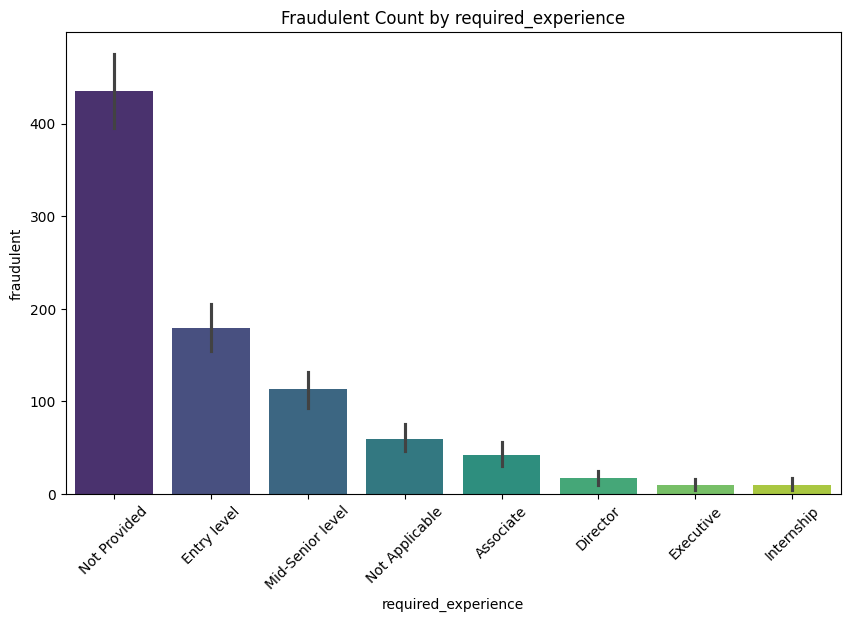

In [21]:
plt.figure(figsize=(10,6))
order = df.groupby('required_experience')['fraudulent'].sum().sort_values(ascending=False).index
sns.barplot(x='required_experience', y='fraudulent', data=df, palette='viridis', estimator=sum, order=order)
plt.title(f'Fraudulent Count by required_experience')
plt.xticks(rotation=45)
plt.show()

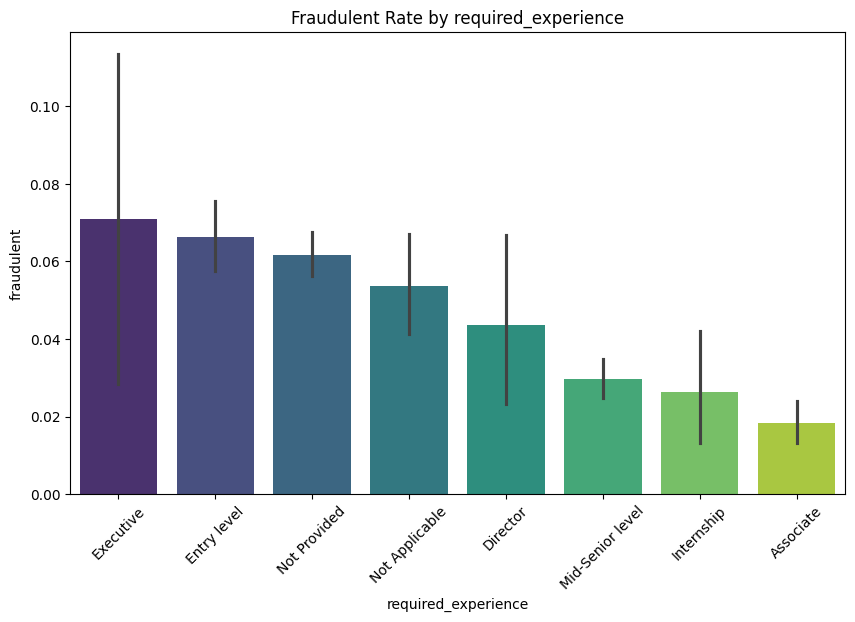

In [22]:
plt.figure(figsize=(10,6))
order = df.groupby('required_experience')['fraudulent'].mean().sort_values(ascending=False).index
sns.barplot(x='required_experience', y='fraudulent', data=df, palette='viridis', order=order)
plt.title(f'Fraudulent Rate by required_experience')
plt.xticks(rotation=45)
plt.show()

> Majority of the job postings that `do not highlight a required experience` are fraudulent.
>
> However, majority of executive job postings are seen to have a `higher percentage` of fraudulent postings.

##### Required Education

In [23]:
print(f"Number of required education levels: {df['required_education'].value_counts().size}")

Number of required education levels: 14


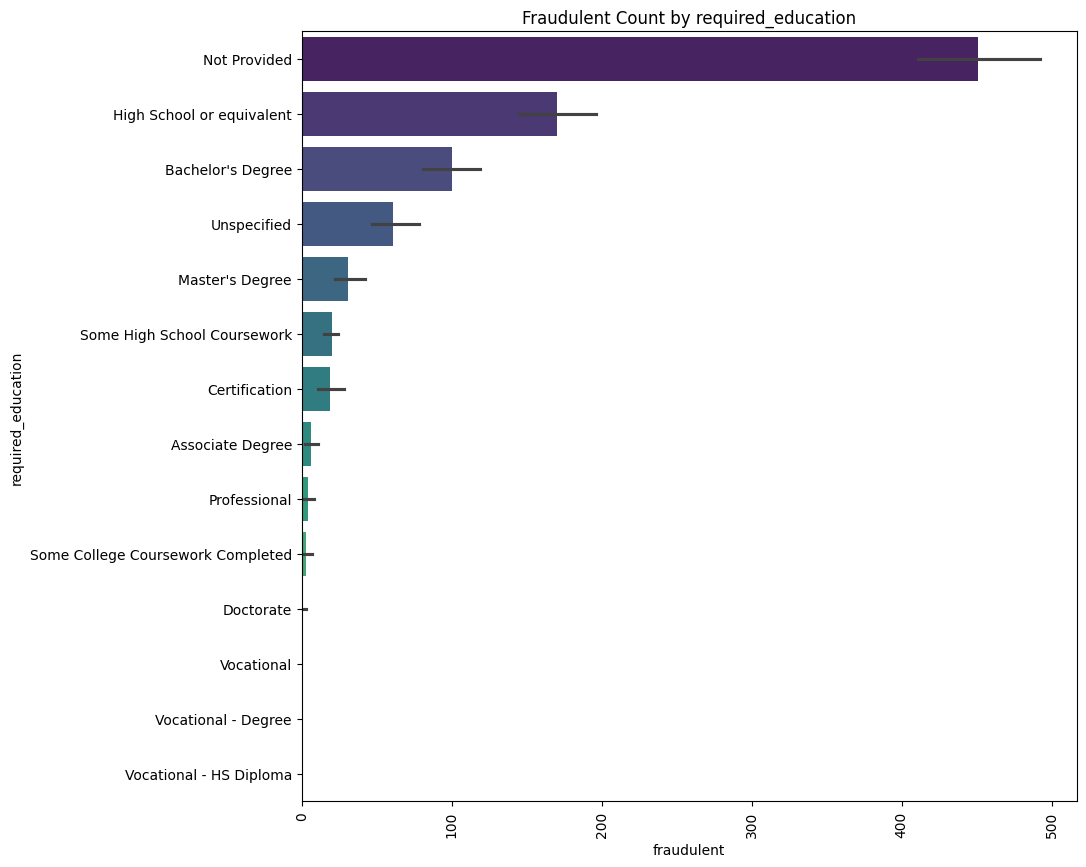

In [24]:
plt.figure(figsize=(10,10))
order = df.groupby('required_education')['fraudulent'].sum().sort_values(ascending=False).index
sns.barplot(y='required_education', x='fraudulent', data=df, palette='viridis', estimator=sum, order=order)
plt.title(f'Fraudulent Count by required_education')
plt.xticks(rotation=90)
plt.show()

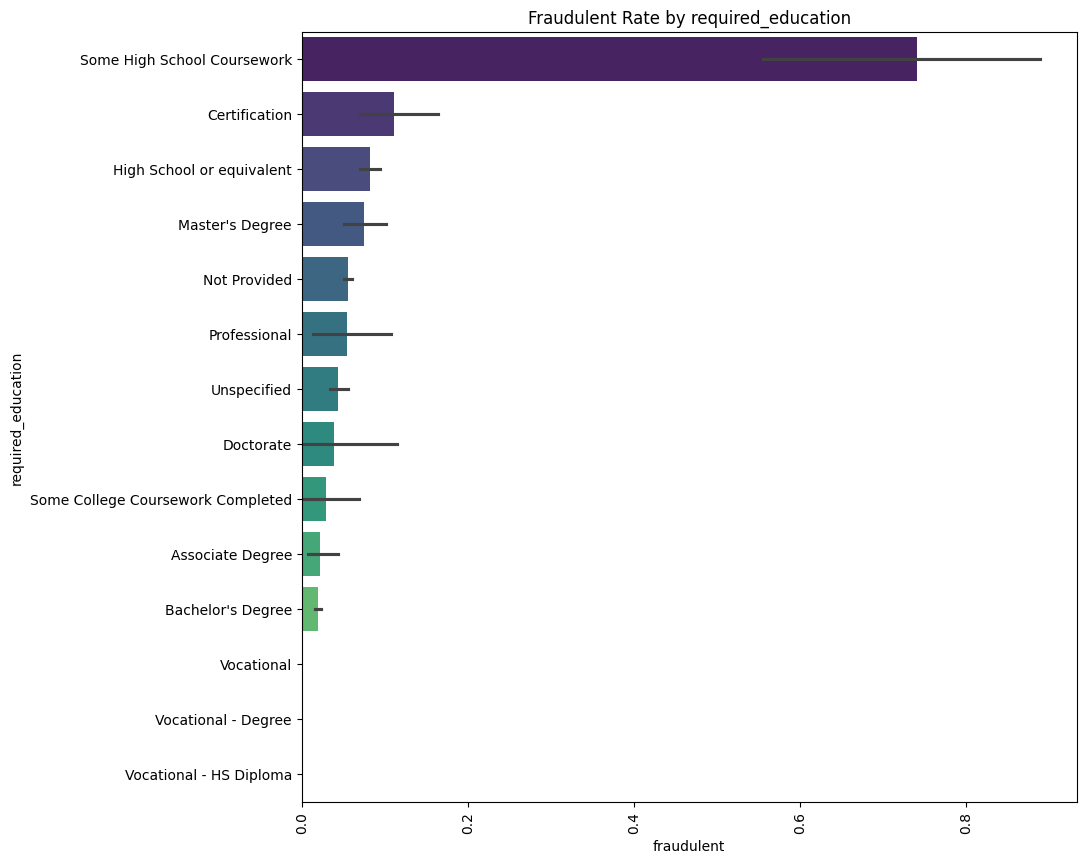

In [25]:
plt.figure(figsize=(10,10))
order = df.groupby('required_education')['fraudulent'].mean().sort_values(ascending=False).index
sns.barplot(y='required_education', x='fraudulent', data=df, palette='viridis', order=order)
plt.title(f'Fraudulent Rate by required_education')
plt.xticks(rotation=90)
plt.show()

>Majority of fraudulent postings `do not have a specified education`.
>
>However, a significant proportion of job postings that `only required high school education` are considered fraudulent.

##### Function

In [26]:
print(f"Number of functions: {df['function'].value_counts().size}")

Number of functions: 38


38 function categories

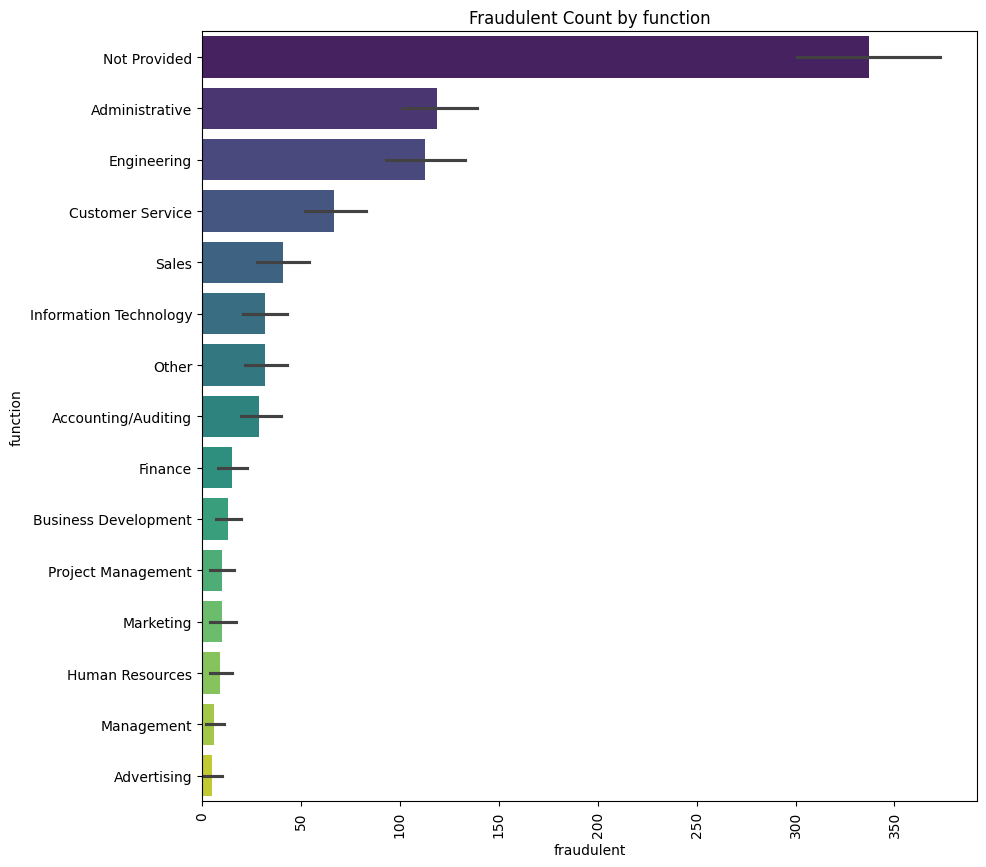

In [27]:
plt.figure(figsize=(10,10))
order = df.groupby('function')['fraudulent'].sum().sort_values(ascending=False).head(15).index
sns.barplot(y='function', x='fraudulent', data=df, palette='viridis', estimator=sum, order=order)
plt.title(f'Fraudulent Count by function')
plt.xticks(rotation=90)
plt.show()

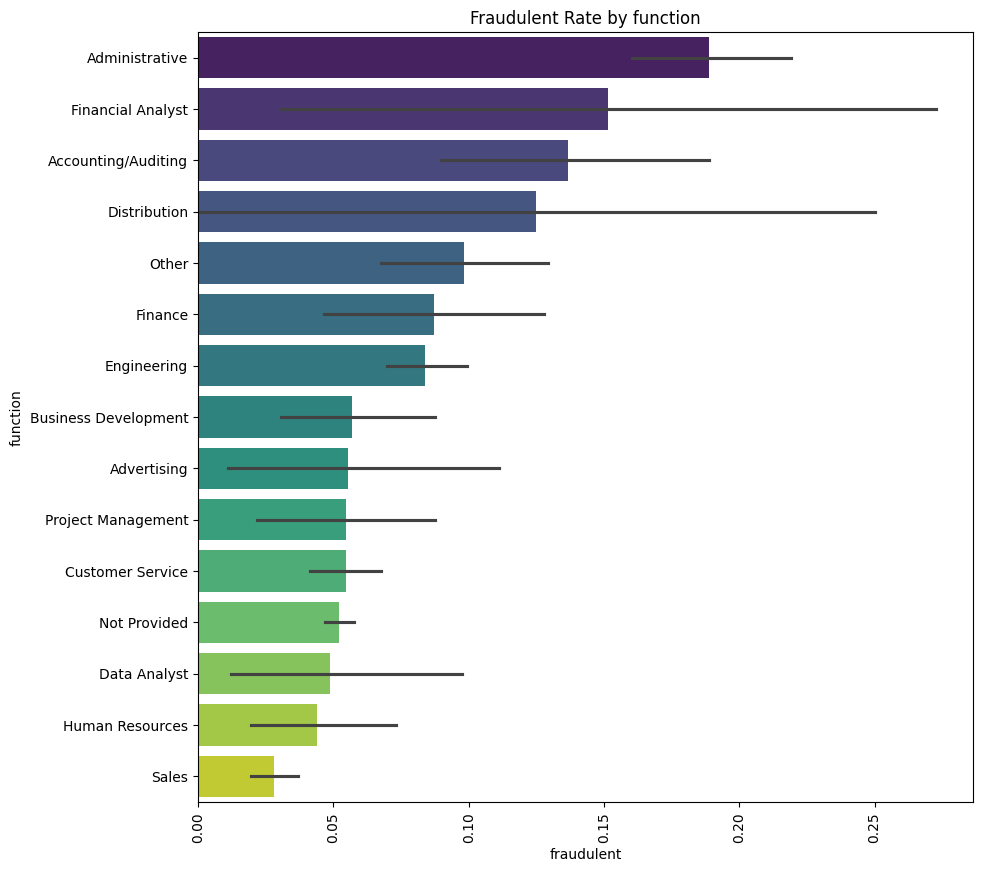

In [28]:
plt.figure(figsize=(10,10))
order = df.groupby('function')['fraudulent'].mean().sort_values(ascending=False).head(15).index
sns.barplot(y='function', x='fraudulent', data=df, palette='viridis', order=order)
plt.title(f'Fraudulent Rate by function')
plt.xticks(rotation=90)
plt.show()

> Majority of fraudulent postings `do not have a specified function`
> 
> However, `administrative functions` have the highest proportion of fraudulent job postings.

##### Industry

In [29]:
print(f"Number of industries: {df['industry'].value_counts().size}")

Number of industries: 132


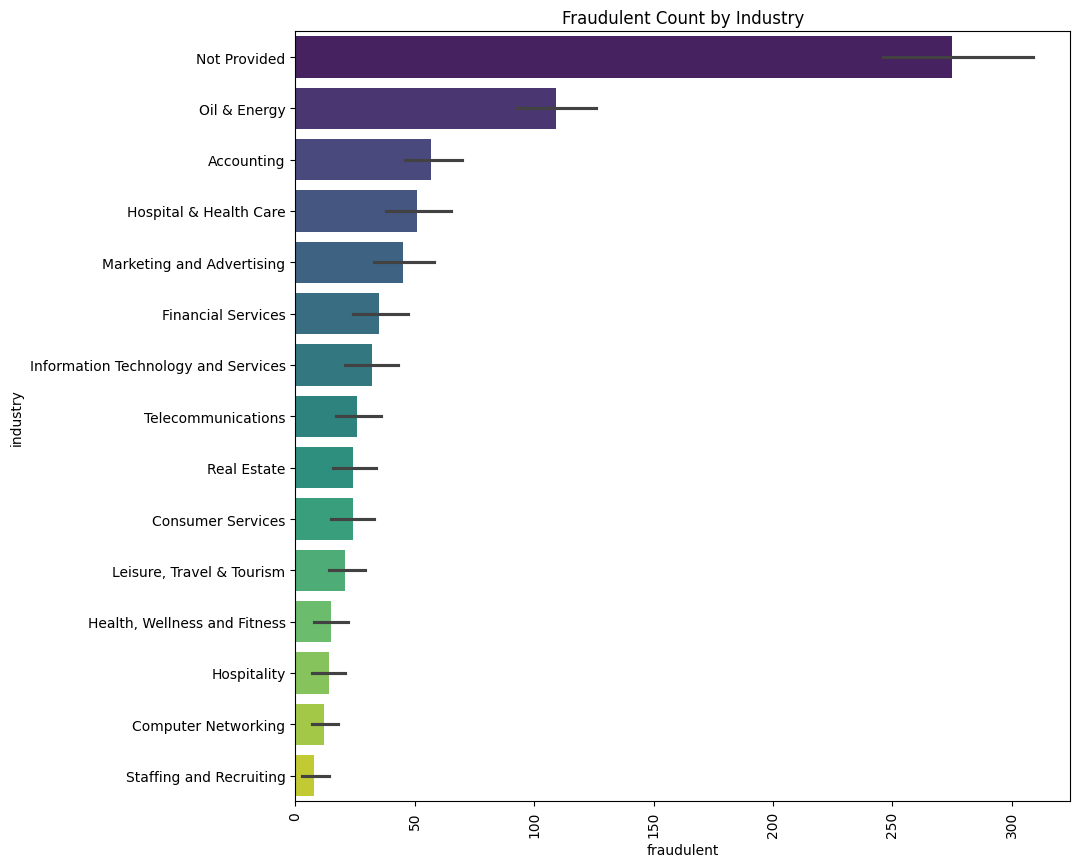

In [30]:
plt.figure(figsize=(10,10))
order = df.groupby('industry')['fraudulent'].sum().sort_values(ascending=False).head(15).index
sns.barplot(y='industry', x='fraudulent', data=df, palette='viridis', estimator=sum, order=order)
plt.title(f'Fraudulent Count by Industry')
plt.xticks(rotation=90)
plt.show()

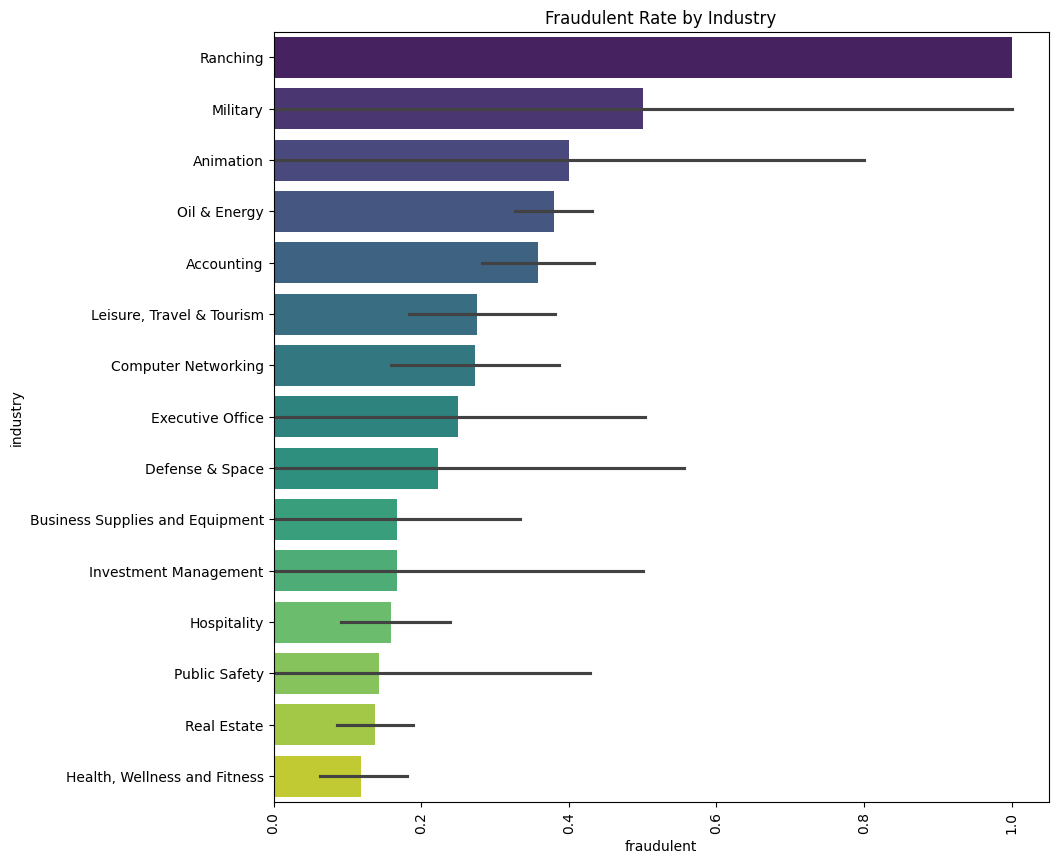

In [31]:
plt.figure(figsize=(10,10))
order = df.groupby('industry')['fraudulent'].mean().sort_values(ascending=False).head(15).index
sns.barplot(y='industry', x='fraudulent', data=df, palette='viridis', order=order)
plt.title(f'Fraudulent Rate by Industry')
plt.xticks(rotation=90)
plt.show()

>Majority of fraudulent jobs `have no industry`
>
>However, `public safety` has the highest proportion of fraudulent jobs

##### Country

In [32]:
print(f"No. of Countries: {df['country'].value_counts().size}")

No. of Countries: 91


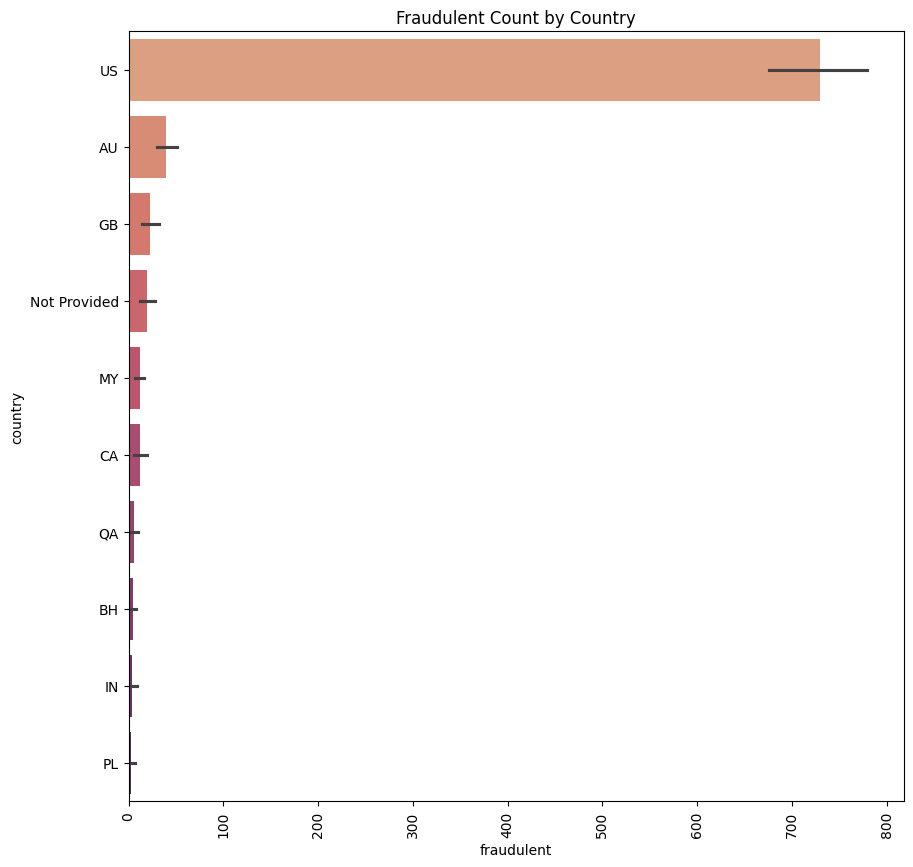

In [33]:
plt.figure(figsize=(10,10))
order = df.groupby('country')['fraudulent'].sum().sort_values(ascending=False).head(10).index
sns.barplot(y='country', x='fraudulent', data=df, palette='flare', estimator=sum, order=order)
plt.title(f'Fraudulent Count by Country')
plt.xticks(rotation=90)
plt.show()

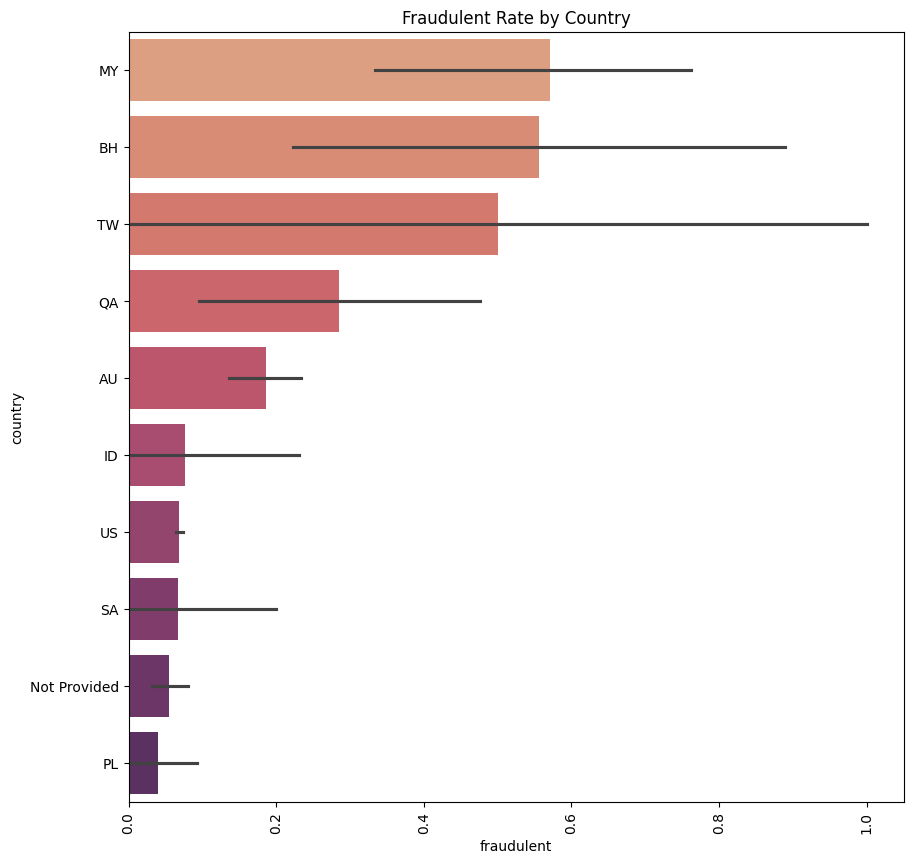

In [34]:
plt.figure(figsize=(10,10))
order = df.groupby('country')['fraudulent'].mean().sort_values(ascending=False).head(10).index
sns.barplot(y='country', x='fraudulent', data=df, palette='flare', order=order)
plt.title(f'Fraudulent Rate by Country')
plt.xticks(rotation=90)
plt.show()

>Majority of fraudulent jobs come from `US, Australia and Great Britain`
>
>However, the highest fraudulent rate for fake jobs occurs in `Malaysia, Bahrain, Australia`


##### State, City

In [35]:
print(f"No. of States: {df['state'].value_counts().size}")

print(f"No. of Cities: {df['city'].value_counts().size}")

No. of States: 326
No. of Cities: 2389


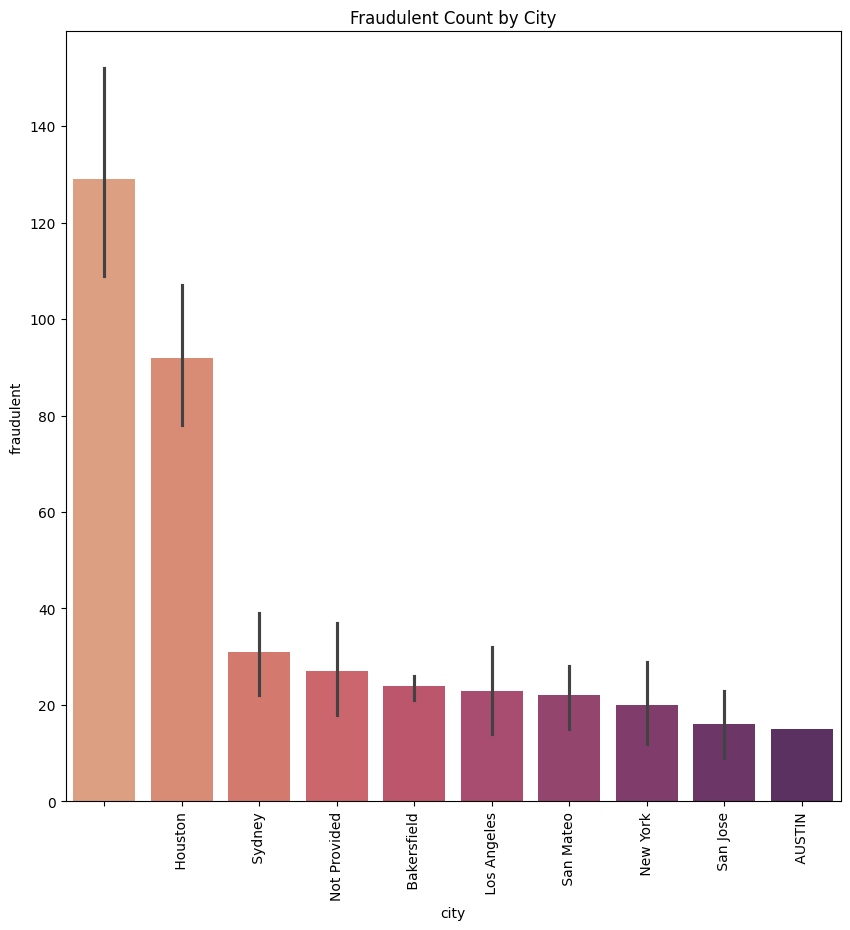

In [36]:
plt.figure(figsize=(10,10))
order = df.groupby('city')['fraudulent'].sum().sort_values(ascending=False).head(10).index
sns.barplot(x='city', y='fraudulent', data=df, palette='flare', estimator=sum, order=order)
plt.title(f'Fraudulent Count by City')
plt.xticks(rotation=90)
plt.show()

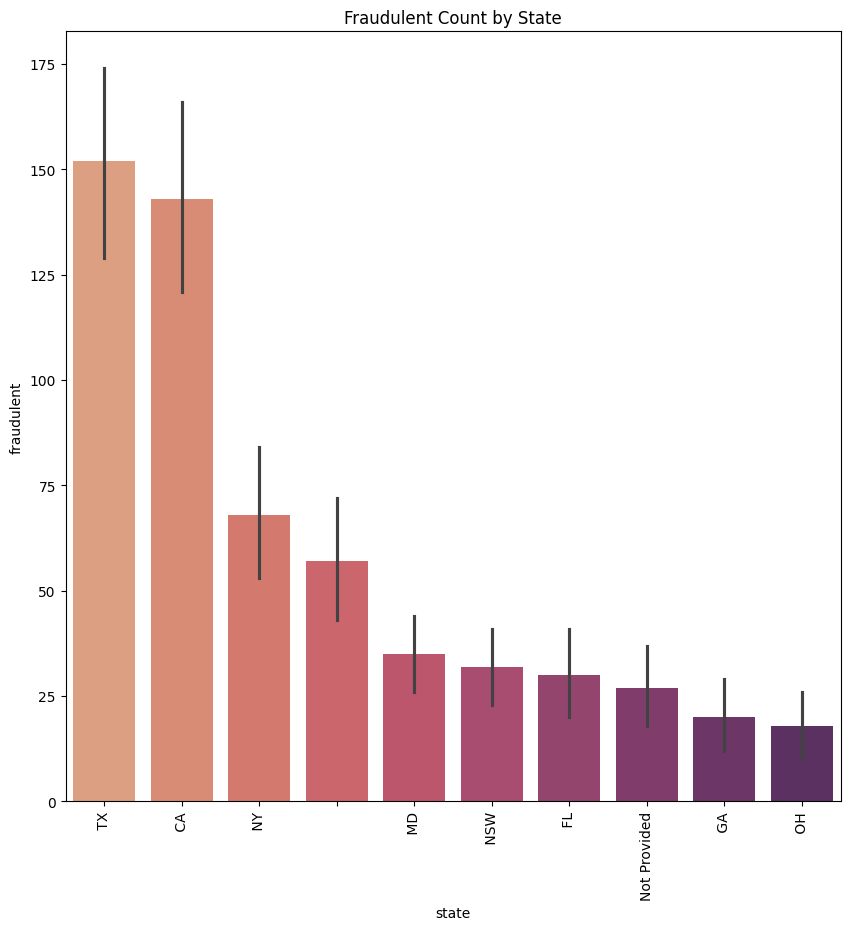

In [37]:
plt.figure(figsize=(10,10))
order = df.groupby('state')['fraudulent'].sum().sort_values(ascending=False).head(10).index
sns.barplot(x='state', y='fraudulent', data=df, palette='flare', estimator=sum, order=order)
plt.title(f'Fraudulent Count by State')
plt.xticks(rotation=90)
plt.show()

>Majority of fraudulent jobs have `no specified city`
>
>Most common states which have fraudulent jobs include `Texas, California, and those with no specified state`

In [38]:
# Check if BOTH State and City are missing
df['vague_location'] = (df['state']=='Not Provided') & (df['city'] == 'Not Provided')
df['vague_location'] = df['vague_location'].astype(int)

# Check the Fraud Rate
vague_rate = df.groupby('vague_location')['fraudulent'].mean()
print("Fraud Rate: Vague (1) vs Specific (0) Locations:")
print(vague_rate)

Fraud Rate: Vague (1) vs Specific (0) Locations:
vague_location
0    0.048108
1    0.061364
Name: fraudulent, dtype: float64


> We can see that job postings `missing both state and city` have a higher chance of being fake
>
> We will add column `vague_location` as a feature

#### (c) Free Text Column Analaysis

Preprocess the texts by removing common punctuations via Regex and common stop words to prevent miscalculation on the importance of seen words.

Use word cloud to give a basic visualisation of the spread of the words in the free text.

Use TF-IDF to give statistics on the contextual importance of the words used in these free text.



In [39]:
df['title'].head(10)

0                             Marketing Intern
1    Customer Service - Cloud Video Production
2      Commissioning Machinery Assistant (CMA)
3            Account Executive - Washington DC
4                          Bill Review Manager
5                             Accounting Clerk
6                        Head of Content (m/f)
7             Lead Guest Service Specialist   
8                                   HP BSM SME
9      Customer Service Associate - Part Time 
Name: title, dtype: str

In [40]:
print(STOPWORDS)
custom_stopwords = STOPWORDS.union({"will", "want", "able","amp", "#URL", "link", "url"})

def plot_wordcloud(text_data,title,color):
    
    combined_text = " ".join(text_data)
    wc =  WordCloud(
        width=800,
        height=400,
        colormap=color,
        stopwords=custom_stopwords
    ).generate(combined_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title)
    plt.axis("off")
    plt.show()

{'be', 'so', "when's", "he'd", 'again', "doesn't", 'their', 'or', "they'll", 'where', 'has', "i'd", 'herself', 'for', 'nor', 'which', 'very', 'why', 'not', 'that', 'all', 'r', 'would', 'however', 'we', "i've", "what's", 'should', 'a', 'is', "he'll", 'he', 'by', 'get', "they've", 'yourselves', 'they', 'too', 'itself', 'own', 'ever', "she'd", 'its', 'otherwise', "mustn't", "shan't", 'both', 'having', 'therefore', 'such', "we've", "she's", "you'd", 'could', 'being', 'like', 'during', 'theirs', "you'll", 'more', 'ought', 'http', 'in', 'from', 'then', 'this', 'down', 'else', 'just', 'between', "how's", 'of', "who's", 'yours', "you're", 'but', 'himself', 'can', "can't", 'an', 'who', "it's", 'at', "we're", 'also', 'since', 'off', 'i', 'as', 'on', 'whom', "i'll", 'some', "here's", 'how', 'ours', 'against', 'most', "why's", "you've", 'do', 'here', "we'd", 'doing', 'into', 'than', 'been', 'while', 'hence', 'his', 'k', 'under', "he's", 'and', "wouldn't", "shouldn't", 'your', "couldn't", 'are', 't

We will implement a custom stopword to remove links and urls commonly seen in the texts. 

In [41]:
fake_job_titles = df[df['fraudulent'] == 1]['title']
real_job_titles = df[df['fraudulent'] == 0]['title']

fake_job_profile = df[df['fraudulent'] == 1]['company_profile']
real_job_profile = df[df['fraudulent'] == 0]['company_profile']

fake_job_description = df[df['fraudulent'] == 1]['description']
real_job_description = df[df['fraudulent'] == 0]['description']

fake_job_requirements = df[df['fraudulent'] == 1]['requirements']
real_job_requirements = df[df['fraudulent'] == 0]['requirements']

fake_job_benefits = df[df['fraudulent'] == 1]['benefits']
real_job_benefits = df[df['fraudulent'] == 0]['benefits']

##### Job Titles

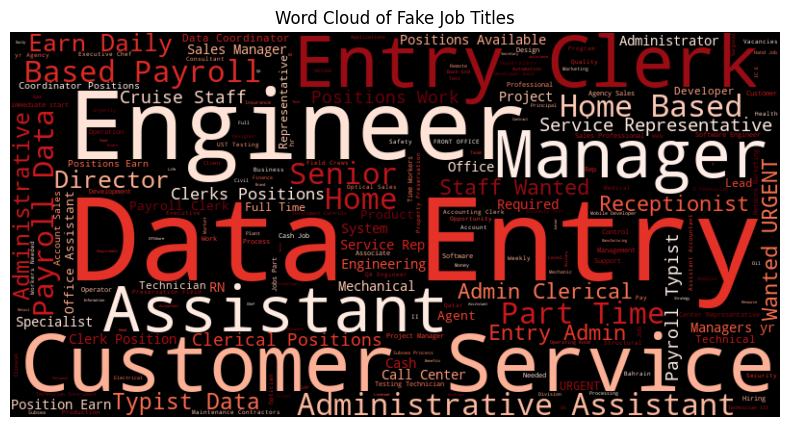

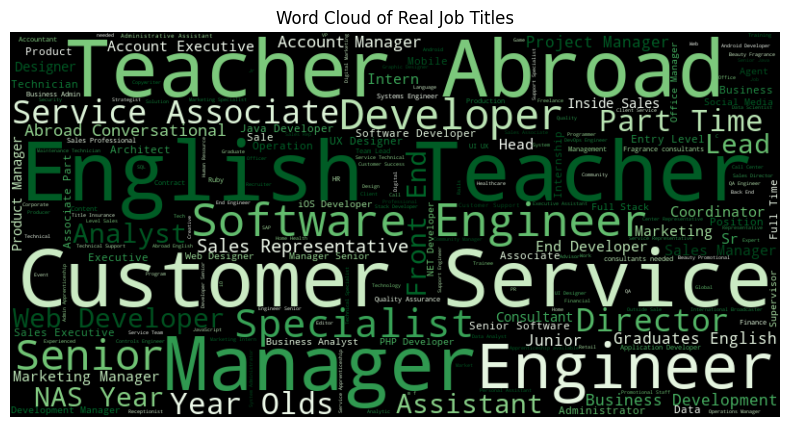

In [42]:
plot_wordcloud(fake_job_titles, 'Word Cloud of Fake Job Titles',"Reds")
plot_wordcloud(real_job_titles, 'Word Cloud of Real Job Titles',"Greens")

>We can see that both fake and real job postings often `commonly feature the same titles` such as customer service, engineer so it may not be as useful as a feature in our model. However, `data entry jobs have a higher probability of being fake`, while `teachers have a higher probability of being real`

##### Company Profiles

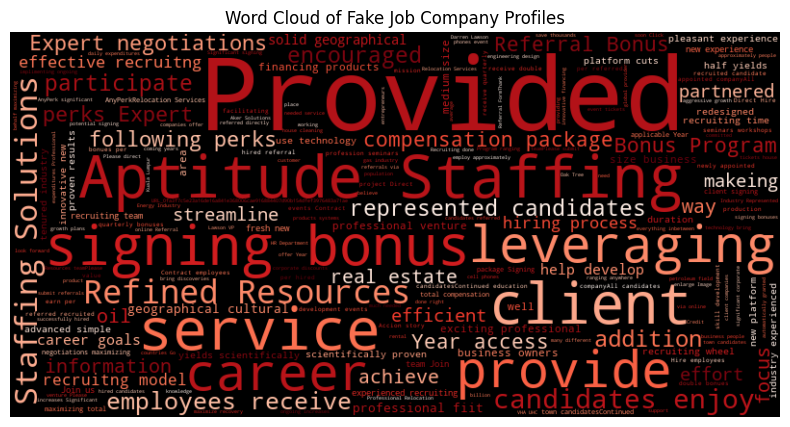

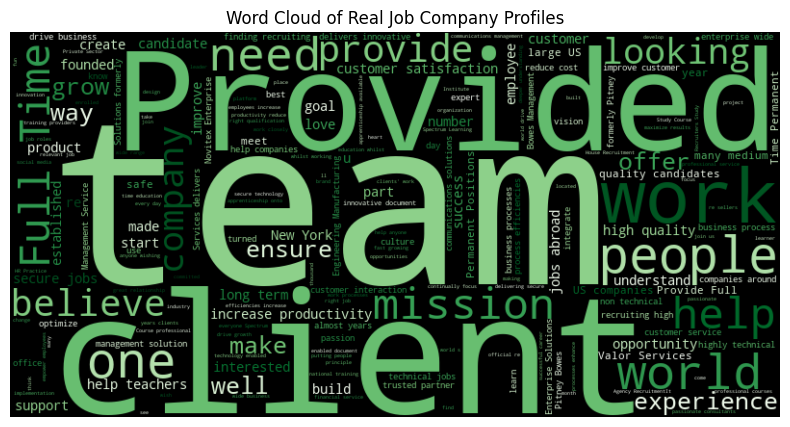

In [43]:
plot_wordcloud(fake_job_profile, 'Word Cloud of Fake Job Company Profiles',"Reds")

plot_wordcloud(real_job_profile, 'Word Cloud of Real Job Company Profiles',"Greens")

>Fake profiles often contain words relating to `high paying careers` such as: signing bonus, aptitude staffing, perks
>
>Real profiles are more `collaborative based` and feature words such as team, client, people

##### Job Requirements

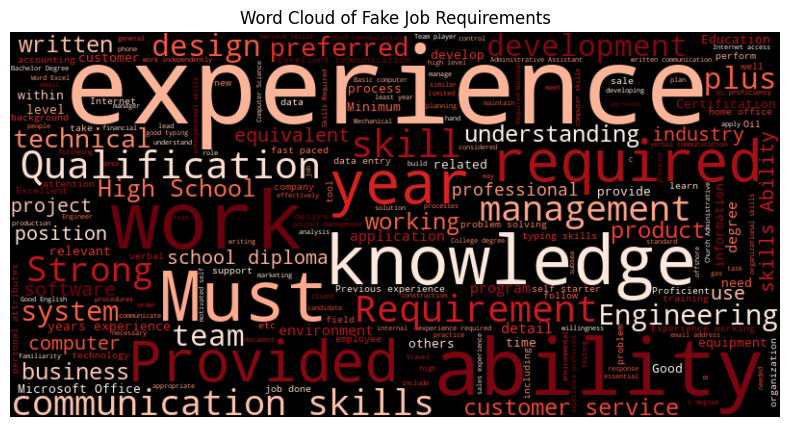

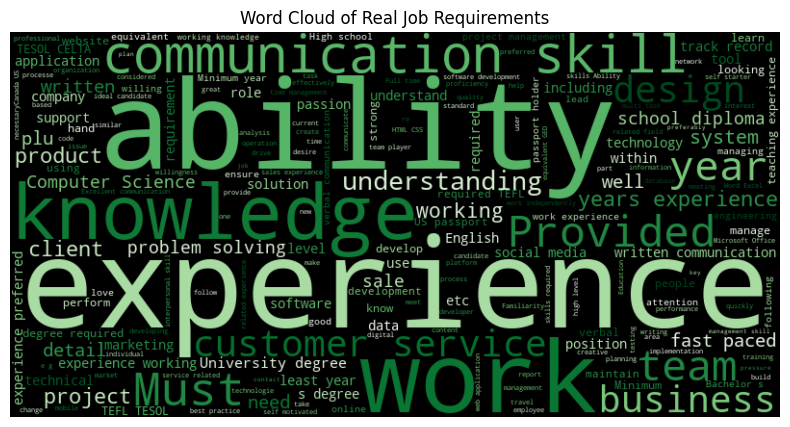

In [44]:
plot_wordcloud(fake_job_requirements, 'Word Cloud of Fake Job Requirements',"Reds")

plot_wordcloud(real_job_requirements, 'Word Cloud of Real Job Requirements',"Greens")

>Both real and fake jobs commonly `feature the same requirements` such as ability, experience
>
>Thus, it `may not be a good indicator` of whether a job is fake or real


##### Job Description

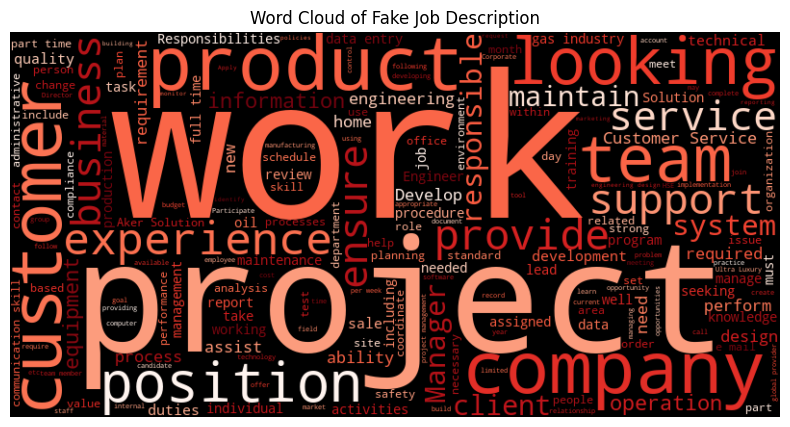

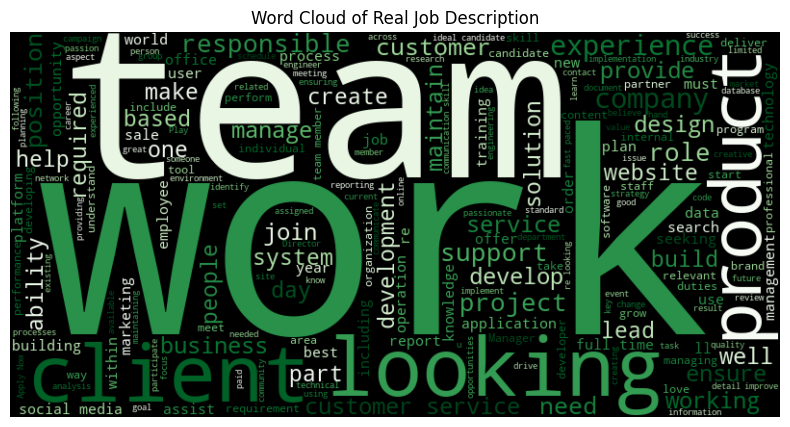

In [45]:
plot_wordcloud(fake_job_description, 'Word Cloud of Fake Job Description',"Reds")

plot_wordcloud(real_job_description, 'Word Cloud of Real Job Description',"Greens")

>The most common words found in fraudulent job postings typically use `simplistic words` like work, data, skills with `little to no specificity to the job` that it is >posting about. Majority of the postings also indicate that it is an entry level job. As such, many of the fraudulent job postings have `simplistic descriptive words` >used and have very little role in explaining the specificity of the job.
>
>In contrast, real job postings are more `role based` and `placing emphasis on teams, business, development`. Key business terms such as marketing, sales and customers are more prevalent in real job postings as well.

### Feature Engineering 

This section serves to engineer new features to discover relationships through the interactions between features.

##### Text Length Analysis

We analyse the `text length and word count` of all text-based columns to find any useful correlation

In [ ]:
for col in text_cols:
    df[f'{col}_len'] = df[col].str.len()
    df[f'{col}_word_count'] = df[col].str.split().str.len().fillna(0).astype(int)
    print(f'{col}_len')
    print(df.groupby('fraudulent')[f'{col}_len'].describe().round(1))
    print(f'{col}_word_count')
    print(df.groupby('fraudulent')[f'{col}_word_count'].describe().round(1))


company_profile_len
              count   mean    std   min    25%    50%    75%     max
fraudulent                                                          
0           17014.0  642.7  566.1   9.0  228.0  588.0  879.0  6178.0
1             866.0  239.0  376.0  12.0   12.0   12.0  410.0  1422.0
company_profile_word_count
              count  mean   std  min   25%   50%    75%    max
fraudulent                                                    
0           17014.0  96.0  85.3  1.0  32.0  86.0  136.0  885.0
1             866.0  33.1  51.6  2.0   2.0   2.0   56.0  220.0
description_len
              count    mean    std  min    25%     50%     75%      max
fraudulent                                                             
0           17014.0  1221.2  889.1  6.0  616.0  1027.0  1589.0  14907.0
1             866.0  1154.8  998.6  9.0  462.5   844.5  1541.0   8578.0
description_word_count
              count   mean    std  min   25%    50%    75%     max
fraudulent                     

>**Company Profile**
>
>Length
>- Real: mean = 640.8 chars, median = 588.0 chars.
>- Fake: mean = 230.9 chars, median = 0.0 chars.
>
>Word Count
>- Real: mean = 96 words, median = 86 words
>- Fake: mean = 33.1 words, median = 2 words
>A median of 0 means over half of fraudulent postings have an `empty company profile`. This is the strongest text-based signal.

>**Description**
>
>Length
>- Real: mean = 1221.2, median = 1027.0.
>- Fake: mean = 1154.8, median = 844.5.
>
>Word Count
>- Real: mean = 171.0, median = 147.0.
>- Fake: mean = 158.8, median = 113.5.
>Both fake and real postings are `relatively similar` so this is a weak signal (844.5 / 1027.0 = 0.82).

>**Requirements**
>
>Length
>- Real: mean = 599.3, median = 476.5.
>- Fake: mean = 448.0, median = 249.0.
>
>Word Count
>- Real: mean = 79.3, median = 63.
>- Fake: mean = 58.8, median = 34.
>Fraudulent postings provide `roughly half the detail` in requirements (249.0 / 476.5 = 0.52).

>**Benefits**
>
>Length
>- Real: mean = 208.7, median = 47.0.
>- Fake: mean = 212.2, median = 36.0.
>
>Word Count
>- Real: mean = 30.8, median = 6.
>- Fake: mean = 30.3, median = 5.
>`Nearly identical` so another weak signal.

**Conclusion:**  We will add `company_profile_len`, `company_profile_word_count`, `description_len`, `description_word_count`, `requirements_len`,`requirements_word_count`. This reinforces the pattern that fraudulent postings appear to omit information. 

In [ ]:
check_cols = ['company_profile', 'description', 'requirements', 'benefits',
              'employment_type', 'required_experience', 'required_education',
              'industry', 'function']

df['missing_count'] = 0
for col in check_cols:
    if col in text_cols:
        df['missing_count'] += (df[col].str.strip() == '').astype(int)
    elif col in cat_cols:
        df['missing_count'] += (df[col] == 'Not Provided').astype(int)

print(pd.crosstab(df['missing_count'], df['fraudulent'], margins=True))
print()
fraud_by_missing = df.groupby('missing_count')['fraudulent'].mean() * 100
print(fraud_by_missing)

fraudulent         0    1    All
missing_count                   
0               7273  342   7615
1               2642   83   2725
2               2077  101   2178
3               1252   89   1341
4               1157   68   1225
5               2613  183   2796
All            17014  866  17880

missing_count
0    4.491136
1    3.045872
2    4.637282
3    6.636838
4    5.551020
5    6.545064
Name: fraudulent, dtype: float64


We will also add a combined `missing_count` or `total_text_length` feature to capture this signal.

In [48]:
df['total_text_len'] = df['company_profile_len'] + df['description_len'] + df['requirements_len'] + df['benefits_len']

print(df.groupby('fraudulent')['total_text_len'].describe().round(1))

              count    mean     std    min     25%     50%     75%      max
fraudulent                                                                 
0           17014.0  2676.7  1453.4  100.0  1599.2  2538.0  3468.0  14943.0
1             866.0  2059.3  1525.6   45.0   928.0  1649.5  2853.8   9730.0


In [49]:
df['salary_provided'] = df['salary_range'].notna().astype(int)

ct = pd.crosstab(df['salary_provided'], df['fraudulent'], margins=True)
ct['fraud_rate'] = ct[1] / ct['All'] * 100
ct['fraud_share'] = ct[1] / 866 * 100
print(ct)

fraudulent           0    1    All  fraud_rate  fraud_share
salary_provided                                            
0                14369  643  15012    4.283240    74.249423
1                 2645  223   2868    7.775453    25.750577
All              17014  866  17880    4.843400   100.000000


In [50]:
df['has_company_profile'] = (df['company_profile'].str.strip() != '').astype(int)

ct = pd.crosstab(df['has_company_profile'], df['fraudulent'], margins=True)
ct['fraud_rate'] = ct[1] / ct['All'] * 100
ct['fraud_share'] = ct[1] / 866 * 100
print(ct)

fraudulent               0    1    All  fraud_rate  fraud_share
has_company_profile                                            
1                    17014  866  17880      4.8434        100.0
All                  17014  866  17880      4.8434        100.0


#### Feature Engineering Summary

**missing_count:**
- Counts the number of empty/unprovided fields across 9 columns (4 text + 5 categorical).
- Fraud rate generally increases with more missing fields: 3.61% at 0 missing, 9.35% at 4, 10.89% at 6, 18.40% at 8.
- Not perfectly linear, certain combinations of missing fields matter more than others but the overall trend is clear.

**total_text_len:**
- Sum of character lengths across company_profile, description, requirements, benefits.
- Fraudulent median: 1,624.5 chars vs legitimate median: 2,530.0 chars (1,624.5 / 2,530.0 = 0.64).
- Confirms fraudulent postings provide less textual content.

**salary_provided:**
- Binary flag: 1 if salary_range was provided, 0 if missing.
- Counterintuitively, postings with a salary have a higher fraud rate: 223 / 2,868 × 100 = 7.78% vs 643 / 15,012 × 100 = 4.28%.
- This goes against the "less info means more fraud" pattern, suggesting fraudsters may use salary as bait.

**has_company_profile:**
- Binary flag: 1 if company_profile is non-empty, 0 if empty.
- Without profile: 587 / 3,308 × 100 = 17.74% fraud rate. With profile: 279 / 14,572 × 100 = 1.91%.
- 587 / 866 × 100 = 67.78% of all fraud cases lack a company profile, the strongest single feature alongside has_company_logo.

**Engineered features to carry forward:** missing_count, total_text_len, company_profile_len, description_len, requirements_len, benefits_len, company_profile_word_count, description_word_count, requirements_word_count, benefits_word_count, salary_provided, has_company_profile.

### Prepping Dataset

This section will serve to prepare the clean dataset to be used for training.

In [ ]:

def remove_terminators(text):
    if isinstance(text, str):
        return re.sub(r'\s+', ' ', text).strip()
    return text

def remove_url(text):
    if isinstance(text,str):
        return re.sub(r'#URL_[a-zA-Z0-9]+', 'link', text)
    return text

def remove_email(text):
    if isinstance(text,str):
        return re.sub(r'#EMAIL_[a-zA-Z0-9]+', 'link', text)
    return text

def remove_phone(text):
    if isinstance(text,str):
        return re.sub(r'#PHONE_[a-zA-Z0-9]+', 'link', text)
    return text

def remove_non_english_words(text):
    if not isinstance(text, str):
        return text
    tokens = text.split()
    filtered = [w for w in tokens if re.search(r'[a-zA-Z0-9]', w)]
    return ' '.join(filtered)


def add_word_boundaries(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'([A-Z]{2,})([A-Z][a-z])', r'\1 \2', text)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    text = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', text)
    text = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', text)
    text = re.sub(r'([.,!?;:])([a-zA-Z])', r'\1 \2', text)
    return text

def split_merged_words(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'([A-Z]{2,})([A-Z][a-z])', r'\1 \2', text)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    return text

def clean_bullet_artifacts(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r'\b\d+\.\s*', ' ', text)        
    text = re.sub(r'\.\d+\.', ' ', text)           
    text = re.sub(r'[•\-–—]+\s*', ' ', text)       
    return text



def clean_job_text(text):
    if not isinstance(text, str):
        return ""


    text = html.unescape(text)
    

    text = BeautifulSoup(text, "html.parser").get_text()

    text = add_word_boundaries(text)


    text = text.lower()


    text = text.replace("not provided", " ")


    contractions = {"we're": "we are", "don't": "do not", "it's": "it is", "we've": "we have"}
    for word, replacement in contractions.items():
        text = text.replace(word, replacement)


    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', ' ', text)


    text = re.sub(r'\s+', ' ', text).strip()

    return text

def clean_job_text_pipeline(text):
    text = remove_url(text)
    text = remove_email(text)
    text = remove_phone(text)
    text = add_word_boundaries(text)
    text = clean_bullet_artifacts(text)
    text = remove_non_english_words(text)
    text = remove_terminators(text)
    text = clean_job_text(text)
    return text



text_cols = ['title', 'country', 'state', 'city', 'company_profile', 'description', 'requirements', 'benefits',"employment_type", "required_experience", "required_education", "industry", "function"]
for col in text_cols:
    df[col] = df[col].apply(clean_job_text_pipeline)


In [53]:
df["employment_type"].value_counts()
df["required_education"].value_counts()

required_education
                                     8105
bachelor s degree                    5145
high school or equivalent            2080
unspecified                          1397
master s degree                       416
associate degree                      274
certification                         170
some college coursework completed     102
professional                           74
vocational                             49
some high school coursework            27
doctorate                              26
vocational hs diploma                   9
vocational degree                       6
Name: count, dtype: int64

In [ ]:
text_cols = ['title', 'country', 'state', 'city', 'company_profile', 'description', 'requirements', 'benefits',
             "employment_type", "required_experience", "required_education", "industry", "function"]
df["full_text"] = df[text_cols].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)
df["full_text"] = df["full_text"].apply(clean_job_text_pipeline)

numeric_cols = ["telecommuting", "missing_count", "total_text_len", "company_profile_len", "description_len", 
                "requirements_len", "company_profile_word_count", "description_word_count", 
                "requirements_word_count", "salary_provided", "has_company_profile",
                "vague_location", "has_company_logo", "has_questions"]

non_binary_cols = ["total_text_len", "company_profile_len", "description_len", "requirements_len",
                   "company_profile_word_count", "description_word_count", "requirements_word_count"]

for col in non_binary_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    print(f"{col} has {len(outliers)} outliers removed")

all_cols = ['full_text'] + numeric_cols + ['fraudulent']
combined_df = df[all_cols]
print(combined_df.shape)
combined_df.head()

combined_df.to_csv('data/clean/fake_job_postings_ALL.csv', index=False)

total_text_len has 361 outliers removed
company_profile_len has 428 outliers removed
description_len has 575 outliers removed
requirements_len has 557 outliers removed
benefits_len has 1243 outliers removed
company_profile_word_count has 30 outliers removed
description_word_count has 142 outliers removed
requirements_word_count has 214 outliers removed
benefits_word_count has 1027 outliers removed
(13303, 18)
